In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# PORT 20260831b.ipynb. Ten notebook nie liczy statystyki sam - czyta zapisane
# krzywe. Port polega WYLACZNIE na tym, ze czyta teraz pliki credo_* (nowa
# konwencja, 20260906a.ipynb) zamiast finetune_*, a swoje wyjscia zapisuje
# z przedrostkiem credo_, zeby nie nadpisac wynikow z sierpnia i wrzesnia.
# Kod analityczny, reguly odczytu i wykresy sa NIETKNIETE.
# Powod zmiany konwencji: dziennik 20260905.txt pkt 13a-13g.
# ==========================================================================

# 31.08.2026 - Watek 2 (PRIORYTET) z planu 20260831/20260831_plan.md:
# kontrola do artykulu + penalizacja prob wielokrotnych (post-trial sigma),
# BEZ Monte Carlo. To pierwsza OBRONIONA liczba istotnosci w tym projekcie -
# dokladnie to, o co Homola prosi od 24.07 (patrz
# project_homola_review_feedback.md w pamieci Claude'a).
#
# WAZNE: dokladne cytaty/liczby z artykulu w tym notebooku pochodza z
# BEZPOSREDNIEGO odczytania zrodla/GlownyArtykul.pdf, sekcja 3-4 (str. 3-5),
# zrobionego w tej sesji - NIE z podgladu Opusa w planie 20260831_plan.md,
# ktory byl w tym miejscu przyblizony/niepelny (m.in. nie doprecyzowal,
# ktory faktor kary idzie z ktorym minimum - patrz Krok 1 nizej).
#
# WEJSCIE: results/credo_mosc_..._fullhistory.csv (krzywa Moskwy, do
# kontroli punktowej) i results/section4_network_minima.csv (wlasne
# znalezione minima wszystkich 20 stacji, wyjscie Watku 1, 20260831a.ipynb)
# - zero nowych skanow.
import numpy as np
import pandas as pd
from scipy.stats import norm

RESULTS_DIR = "../results"

mosc = pd.read_csv(f"{RESULTS_DIR}/credo_mosc_P3350_d5_dt15_fullhistory.csv",
                    parse_dates=["t0"]).sort_values("t0").reset_index(drop=True)
network_minima = pd.read_csv(f"{RESULTS_DIR}/credo_section4_network_minima.csv",
                              parse_dates=["t0_h5", "t0_h6", "station_t0_min", "station_t0_max"])

STATIONS = sorted(network_minima["station"].unique())
print(f"mosc: {len(mosc)} punktow, {mosc['t0'].min().date()} .. {mosc['t0'].max().date()}")
print(f"network_minima: {len(network_minima)} wierszy, {len(STATIONS)} stacji")

mosc: 74322 punktow, 1965-01-01 .. 2015-11-15
network_minima: 140 wierszy, 20 stacji


In [2]:
# Krok 1: rozszyfrowanie faktorow kary z sekcji 4 artykulu. Artykul podaje
# w tekscie i we wzorze produktu (str. 5) explicite pary (PPDF, faktor) dla
# 4 minimow, w tej kolejnosci:
#   (3.34e-8, 3430), (3.0e-6, 2682), (3.58e-5, 1952), (2.92e-6, 1207)
# odpowiadajace czterem datom (wszystkie 07:37:12 GMT):
#   min1: 12 Jul 1969, min2: 11 Jul 1978, min3: 21 Sep 1988, min4: 23 Dec 1999
# Artykul NIE tlumaczy skad biora sie liczby 3430/2682/1952/1207. Testujemy
# hipoteze (uzasadniona cytatem: "the scan of the new sets can be continued
# only beginning from the first t0 value after the previous minimum"):
#
#   faktor(min_i) = liczba krokow 5-dniowych OD DATY POPRZEDNIEGO minimum
#                   (min_{i-1}) DO granicy "burning sample" (2005-03-30,
#                   pierwszy rekord Augera - podane wprost w sekcji 3
#                   artykulu), NIE od daty samego min_i.
#
# Intuicja: raz znalazlszy min_{i-1}, budzet prob na natrafienie na KOLEJNE
# (min_i) to caly pozostaly zakres od min_{i-1} do granicy burning sample -
# a nie odleglosc do konkretnej daty min_i, ktorej przeciez jeszcze nie
# znamy w momencie liczenia budzetu.
BURNING_START = pd.Timestamp("2005-03-30")
D_DAYS = 5


def steps_to_boundary(date, boundary=BURNING_START, step_days=D_DAYS):
    return (boundary - date).days / step_days


print("Test hipotezy (faktor(min_i) z daty POPRZEDNIEGO minimum):")
print(f"  faktor(min2)=2682, z daty min1 DRUKOWANEJ (1969-07-12): "
      f"{steps_to_boundary(pd.Timestamp('1969-07-12 07:37:12')):.1f}")
print(f"  faktor(min2)=2682, z daty min1 SKORYGOWANEJ (1968-07-12): "
      f"{steps_to_boundary(pd.Timestamp('1968-07-12 07:37:12')):.1f}  <- niemal dokladne trafienie")
print(f"  faktor(min3)=1952, z daty min2 (1978-07-11): "
      f"{steps_to_boundary(pd.Timestamp('1978-07-11 07:37:12')):.1f}  <- niemal dokladne trafienie")
print(f"  faktor(min4)=1207, z daty min3 (1988-09-21): "
      f"{steps_to_boundary(pd.Timestamp('1988-09-21 07:37:12')):.1f}  <- niemal dokladne trafienie")
print()
print("faktor(min1)=3430 nie ma 'poprzedniego minimum' - powinien odpowiadac")
print("odleglosci OD POCZATKU DANYCH MOSKWY uzywanych w artykule:")
data_start_implied = BURNING_START - pd.Timedelta(days=D_DAYS * 3430)
print(f"  data implikowana przez faktor 3430: {data_start_implied.date()}")
print(f"  (nasze wlasne dane Moskwy w tym repo zaczynaja sie {mosc['t0'].min().date()} -"
      f" pozniej, bo limitowane katalogiem EQ od 1965, patrz komorka nizej)")
print()
print("WNIOSEK: trzy z czterech faktorow (2682/1952/1207) niemal idealnie")
print("odtwarzaja hipoteze 'od poprzedniego minimum do burning sample', pod")
print("warunkiem POPRAWIENIA drukowanej daty min1 z 1969 na 1968 - to NIEZALEZNE")
print("(inne niz w planie Opusa) potwierdzenie literowki w artykule w roku")
print("pierwszego minimum. Faktor 3430 (dla min1) odpowiada nie odleglosci do")
print("min1, tylko odleglosci od poczatku danych Moskwy - to jest budzet prob")
print("na ZNALEZIENIE PIERWSZEGO minimum w calej dostepnej historii.")

Test hipotezy (faktor(min_i) z daty POPRZEDNIEGO minimum):
  faktor(min2)=2682, z daty min1 DRUKOWANEJ (1969-07-12): 2608.8
  faktor(min2)=2682, z daty min1 SKORYGOWANEJ (1968-07-12): 2681.8  <- niemal dokladne trafienie
  faktor(min3)=1952, z daty min2 (1978-07-11): 1951.6  <- niemal dokladne trafienie
  faktor(min4)=1207, z daty min3 (1988-09-21): 1206.6  <- niemal dokladne trafienie

faktor(min1)=3430 nie ma 'poprzedniego minimum' - powinien odpowiadac
odleglosci OD POCZATKU DANYCH MOSKWY uzywanych w artykule:
  data implikowana przez faktor 3430: 1958-04-16
  (nasze wlasne dane Moskwy w tym repo zaczynaja sie 1965-01-01 - pozniej, bo limitowane katalogiem EQ od 1965, patrz komorka nizej)

WNIOSEK: trzy z czterech faktorow (2682/1952/1207) niemal idealnie
odtwarzaja hipoteze 'od poprzedniego minimum do burning sample', pod
warunkiem POPRAWIENIA drukowanej daty min1 z 1969 na 1968 - to NIEZALEZNE
(inne niz w planie Opusa) potwierdzenie literowki w artykule w roku
pierwszego minimum. 

In [3]:
# Krok 2: kontrola punktowa do artykulu. Dla piatego dat z sekcji 4 (dla
# min1 sprawdzamy OBA warianty roku: drukowany 1969 i domniemany poprawny
# 1968 - patrz Krok 1), wypisujemy z NASZEJ krzywej Moskwy PPDF dokladnie w
# tej dacie (najblizszy punkt siatki 6h) oraz najlepszy lokalny punkt w
# oknie +-180 dni, obok wartosci opublikowanej w artykule. Piate minimum
# (2009-02-23) jest wewnatrz burning sample - nie wchodzi do iloczynu
# istotnosci (Krok 3/4), ale kontrolujemy je tez punktowo dla kompletnosci
# (to jest ten sam punkt zweryfikowany juz 24.08, 20260824f.ipynb).
control_points = [
    ("min1 drukowane (1969-07-12)", pd.Timestamp("1969-07-12 07:37:12"), 3.34e-8),
    ("min1 skorygowane (1968-07-12)", pd.Timestamp("1968-07-12 07:37:12"), 3.34e-8),
    ("min2 (1978-07-11)", pd.Timestamp("1978-07-11 07:37:12"), 3.0e-6),
    ("min3 (1988-09-21)", pd.Timestamp("1988-09-21 07:37:12"), 3.58e-5),
    ("min4 (1999-12-23)", pd.Timestamp("1999-12-23 07:37:12"), 2.92e-6),
    ("min5 (2009-02-23, w burning sample)", pd.Timestamp("2009-02-23 07:37:12"), 8.1e-9),
]

rows = []
for label, date, ppdf_pub in control_points:
    idx_nearest = (mosc["t0"] - date).abs().idxmin()
    nearest = mosc.loc[idx_nearest]

    window = mosc[(mosc["t0"] >= date - pd.Timedelta(days=180)) & (mosc["t0"] <= date + pd.Timedelta(days=180))]
    best_local = window.loc[window["PPDF"].idxmin()]

    rows.append(dict(
        punkt=label,
        PPDF_publikowane=ppdf_pub,
        t0_najblizszy=nearest["t0"], PPDF_najblizszy=nearest["PPDF"],
        t0_najlepszy_180d=best_local["t0"], PPDF_najlepszy_180d=best_local["PPDF"],
    ))

control_table = pd.DataFrame(rows)
print("Tabela kontrolna (do dziennika):")
control_table

Tabela kontrolna (do dziennika):


,punkt,PPDF_publikowane,t0_najblizszy,PPDF_najblizszy,t0_najlepszy_180d,PPDF_najlepszy_180d
0,min1 drukowane (1969-07-12),3.340000e-08,1969-07-12 06:00:00,1.575390e-02,1969-01-18 18:00:00,1.830386e-06
1,min1 skorygowane (1968-07-12),3.340000e-08,1968-07-12 06:00:00,NaN,1968-03-24 18:00:00,1.903535e-10
2,min2 (1978-07-11),3.000000e-06,1978-07-11 06:00:00,3.276392e-04,1978-05-24 12:00:00,6.360489e-07
3,min3 (1988-09-21),3.580000e-05,1988-09-21 06:00:00,2.029039e-04,1989-03-03 12:00:00,2.091066e-07
4,min4 (1999-12-23),2.920000e-06,1999-12-23 06:00:00,5.412279e-05,2000-04-14 18:00:00,3.344285e-08
5,"min5 (2009-02-23, w burning sample)",8.100000e-09,2009-02-23 06:00:00,9.102874e-07,2008-09-02 00:00:00,3.427913e-09


In [4]:
# Krok 3: odtworzenie rachunku artykulu NA ICH liczbach (kontrola, ze
# rozumiemy przepis poprawnie, zanim uzyjemy go na wlasnych minimach).
# Wzor z sekcji 4, str. 5: iloczyn (PPDF_i x faktor_i) po 4 minimach.
article_terms = [(3.34e-8, 3430), (3.0e-6, 2682), (3.58e-5, 1952), (2.92e-6, 1207)]
article_product = float(np.prod([ppdf * n for ppdf, n in article_terms]))
article_sigma = float(norm.isf(article_product))

print(f"iloczyn = {article_product:.3e}  (artykul podaje: 2.3e-10)")
print(f"sigma   = {article_sigma:.2f}  (artykul podaje: ~6.3)")
print()
print("Male roznice (2.27e-10 vs 2.3e-10, 6.23 vs 6.3) to tylko zaokraglenia")
print("PPDF do 2-3 cyfr znaczacych w tekscie artykulu - przepis jest zrozumiany")
print("poprawnie, mozna go bezpiecznie zastosowac do wlasnych danych (Krok 4-5).")

iloczyn = 2.270e-10  (artykul podaje: 2.3e-10)
sigma   = 6.23  (artykul podaje: ~6.3)

Male roznice (2.27e-10 vs 2.3e-10, 6.23 vs 6.3) to tylko zaokraglenia
PPDF do 2-3 cyfr znaczacych w tekscie artykulu - przepis jest zrozumiany
poprawnie, mozna go bezpiecznie zastosowac do wlasnych danych (Krok 4-5).


In [5]:
# Krok 4: TEN SAM rachunek na WLASNYCH minimach Moskwy znalezionych w
# Watku 1 (20260831a.ipynb, prog=5.0, znak-slepo) - uzywamy tylko minimow
# SPRZED burning sample (4 najstarsze ery: 1968/1978/1988/1999), tak jak
# robi artykul (5. minimum, 2008-09-27, jest wewnatrz burning sample i NIE
# wchodzi do iloczynu istotnosci - dokladnie jak w artykule).
mosc_own = network_minima[(network_minima["station"] == "mosc") & (network_minima["matched_h5"]) &
                           (network_minima["era"] < 2008)].sort_values("t0_h5")
print("Nasze wlasne minima Moskwy uzyte w rachunku:")
print(mosc_own[["era", "t0_h5", "neglog10_PPDF_h5", "sigma_h5"]].to_string(index=False))

mosc_data_start = mosc["t0"].min()
print(f"\nPoczatek naszych danych Moskwy (limitowany katalogiem EQ od 1965): "
      f"{mosc_data_start.date()} (artykul sugeruje ~1958-04-16, patrz Krok 1 -"
      f" nasza probka jest wiec ok. 7 lat krotsza).")

prev = mosc_data_start
our_terms = []
for _, row in mosc_own.iterrows():
    n = (BURNING_START - prev).days / D_DAYS
    ppdf = 10 ** (-row["neglog10_PPDF_h5"])
    our_terms.append((ppdf, n, row["era"]))
    prev = row["t0_h5"]

print("\nera | PPDF | n (budzet prob) | PPDF x n")
for ppdf, n, era in our_terms:
    print(f"{era} | {ppdf:.3e} | {n:8.1f} | {ppdf * n:.3e}")

our_product = float(np.prod([ppdf * n for ppdf, n, _ in our_terms]))
our_sigma = float(norm.isf(our_product))
print(f"\nnasz iloczyn = {our_product:.3e}, sigma = {our_sigma:.2f}  "
      f"(artykul: iloczyn=2.3e-10, sigma=6.3)")

print()
print("UWAGA (WAZNE, nie przemilczac): wychodzi WIECEJ niz w artykule, nie mniej.")
print("Nasze wlasne daty NIE pokrywaja sie dokladnie z datami artykulu (np. era")
print("1988: my 1988-08-30, artykul 1988-09-21; era 1999: my 1999-03-10, artykul")
print("1999-12-23) - Watek 1 szukal NAJGLEBSZEGO punktu w calej erze (find_peaks),")
print("a nie sprawdzal jednej konkretnej daty. To moze systematycznie zanizac PPDF")
print("wzgledem sztywno wskazanej daty artykulu w kazdej erze, wiec licza")
print(f"{our_sigma:.1f} sigma NIE jest bezposrednio porownywalna z {article_sigma:.1f} sigma")
print("artykulu bez dalszej analizy tej roznicy (kandydat na kolejny watek).")

Nasze wlasne minima Moskwy uzyte w rachunku:
 era               t0_h5  neglog10_PPDF_h5  sigma_h5
1968 1968-03-24 18:00:00          9.720439 -6.193715
1978 1978-05-24 12:00:00          6.196509 -4.686907
1988 1989-03-03 12:00:00          6.679632 -4.920705
1999 1999-02-18 00:00:00          7.837100 -5.440359

Poczatek naszych danych Moskwy (limitowany katalogiem EQ od 1965): 1965-01-01 (artykul sugeruje ~1958-04-16, patrz Krok 1 - nasza probka jest wiec ok. 7 lat krotsza).

era | PPDF | n (budzet prob) | PPDF x n
1968 | 1.904e-10 |   2939.4 | 5.595e-07
1978 | 6.360e-07 |   2703.8 | 1.720e-03
1988 | 2.091e-07 |   1961.2 | 4.101e-04
1999 | 1.455e-08 |   1174.0 | 1.708e-05

nasz iloczyn = 6.741e-18, sigma = 8.54  (artykul: iloczyn=2.3e-10, sigma=6.3)

UWAGA (WAZNE, nie przemilczac): wychodzi WIECEJ niz w artykule, nie mniej.
Nasze wlasne daty NIE pokrywaja sie dokladnie z datami artykulu (np. era
1988: my 1988-08-30, artykul 1988-09-21; era 1999: my 1999-03-10, artykul
1999-12-23) - Watek

In [6]:
# Krok 5: rozszerzenie na 20 stacji. Per stacja liczymy n_i z JEJ WLASNEGO
# zakresu skanu (data_start = wlasny t0.min() tej stacji, z kolumny
# station_t0_min zapisanej juz w Watku 1 - nie trzeba przeladowywac 20
# plikow finetune). TA SAMA logika co Krok 4. DWA WARIANTY, oba
# raportowane (plan sekcja 3):
#  (a) przepis artykulu: tylko minima SPRZED burning sample (era<2008),
#      ostatni faktor liczony do granicy burning_start.
#  (b) bez wykluczenia (nasza dotychczasowa praktyka): WSZYSTKIE dopasowane
#      ery danej stacji wliczajac 2008, ostatni faktor liczony do konca
#      wlasnego zakresu skanu tej stacji (t0.max()), nie do burning_start.
station_ranges = network_minima.groupby("station").agg(
    data_start=("station_t0_min", "first"), data_end=("station_t0_max", "first"))


def penalized_chain(era_rows, data_start, boundary):
    prev = data_start
    terms = []
    for _, row in era_rows.iterrows():
        n = (boundary - prev).days / D_DAYS
        if n <= 0:
            return None
        ppdf = 10 ** (-row["neglog10_PPDF_h5"])
        terms.append(ppdf * n)
        prev = row["t0_h5"]
    if not terms:
        return None
    product = float(np.prod(terms))
    sigma = float(norm.isf(product)) if 0 < product < 1 else np.nan
    return dict(n_minima=len(terms), product=product, sigma_post_trial=sigma)


results_rows = []
for st in STATIONS:
    st_rows = network_minima[(network_minima["station"] == st) & (network_minima["matched_h5"])].sort_values("t0_h5")
    data_start = station_ranges.loc[st, "data_start"]
    data_end = station_ranges.loc[st, "data_end"]
    calosc_w_burning = data_start >= BURNING_START

    rows_a = st_rows[st_rows["era"] < 2008]
    res_a = penalized_chain(rows_a, data_start, BURNING_START)
    pre_a = rows_a["sigma_h5"].abs().max() if len(rows_a) else np.nan
    results_rows.append(dict(station=st, wariant="a_z_wykluczeniem", calosc_w_burning_sample=calosc_w_burning,
                              pre_trial_sigma=pre_a,
                              **(res_a or dict(n_minima=0, product=np.nan, sigma_post_trial=np.nan))))

    res_b = penalized_chain(st_rows, data_start, data_end)
    pre_b = st_rows["sigma_h5"].abs().max() if len(st_rows) else np.nan
    results_rows.append(dict(station=st, wariant="b_bez_wykluczenia", calosc_w_burning_sample=calosc_w_burning,
                              pre_trial_sigma=pre_b,
                              **(res_b or dict(n_minima=0, product=np.nan, sigma_post_trial=np.nan))))

penalized_table = pd.DataFrame(results_rows)
penalized_table.to_csv(f"{RESULTS_DIR}/credo_section4_penalized_significance.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/credo_section4_penalized_significance.csv, {len(penalized_table)} wierszy")

brak_a = penalized_table[(penalized_table.wariant == "a_z_wykluczeniem") & (penalized_table.n_minima == 0)]
calosc_w_burning_lista = penalized_table[penalized_table["calosc_w_burning_sample"]]["station"].unique().tolist()
print(f"\nStacje BEZ zadnego minimum sprzed burning sample (wariant a, n_minima=0): "
      f"{brak_a['station'].tolist()}")
print(f"Stacje, ktorych CALA historia CR lezy wewnatrz burning sample "
      f"(data_start >= 2005-03-30): {calosc_w_burning_lista}")
print("(dla reszty stacji z pustej listy powyzej: maja dane sprzed 2005, ale nie na")
print("tyle wczesnie/gesto by trafic w erowe okno 1999 (+-2 lata) lub starsze -")
print("zgodne z ostrzezeniem z planu, sekcja 3, Watek 2 krok 6)")

print()
print("UWAGA jak w Kroku 4: wiele stacji w wariancie (a) 'bije' nawet wlasny wynik")
print("artykulu (6.3 sigma) - to ten sam efekt swobodnego wyboru najgleszego punktu")
print("w erze (Watek 1), NIE dowod na mocniejszy efekt niz w artykule. Traktowac")
print("te liczby jako gorny pulap/best-case, nie jako gotowa liczba do publikacji.")

penalized_table.sort_values(["wariant", "station"])

Zapisano ../results/credo_section4_penalized_significance.csv, 40 wierszy

Stacje BEZ zadnego minimum sprzed burning sample (wariant a, n_minima=0): ['apty', 'athn', 'fsmt', 'nain', 'psnm']
Stacje, ktorych CALA historia CR lezy wewnatrz burning sample (data_start >= 2005-03-30): ['psnm']
(dla reszty stacji z pustej listy powyzej: maja dane sprzed 2005, ale nie na
tyle wczesnie/gesto by trafic w erowe okno 1999 (+-2 lata) lub starsze -
zgodne z ostrzezeniem z planu, sekcja 3, Watek 2 krok 6)

UWAGA jak w Kroku 4: wiele stacji w wariancie (a) 'bije' nawet wlasny wynik
artykulu (6.3 sigma) - to ten sam efekt swobodnego wyboru najgleszego punktu
w erze (Watek 1), NIE dowod na mocniejszy efekt niz w artykule. Traktowac
te liczby jako gorny pulap/best-case, nie jako gotowa liczba do publikacji.


,station,wariant,calosc_w_burning_sample,pre_trial_sigma,n_minima,product,sigma_post_trial
0,aatb,a_z_wykluczeniem,False,7.502027,3,1.615864e-20,9.210976
2,apty,a_z_wykluczeniem,False,NaN,0,NaN,NaN
4,athn,a_z_wykluczeniem,False,NaN,0,NaN,NaN
6,fsmt,a_z_wykluczeniem,False,NaN,0,NaN,NaN
8,hrms,a_z_wykluczeniem,False,inf,4,6.344082e-36,12.457762
10,invk,a_z_wykluczeniem,False,5.858057,1,5.353813e-07,4.878167
12,jung,a_z_wykluczeniem,False,6.799394,4,1.587223e-18,8.705047
14,jung1,a_z_wykluczeniem,False,4.764817,1,6.208544e-04,3.229122
16,lmks,a_z_wykluczeniem,False,5.545198,2,1.621704e-09,5.918779
18,mosc,a_z_wykluczeniem,False,6.193715,4,6.741273e-18,8.539481


/home/maciej/.local/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/maciej/.local/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/home/maciej/.local/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Zapisano ../results/credo_section4_penalized_significance.png


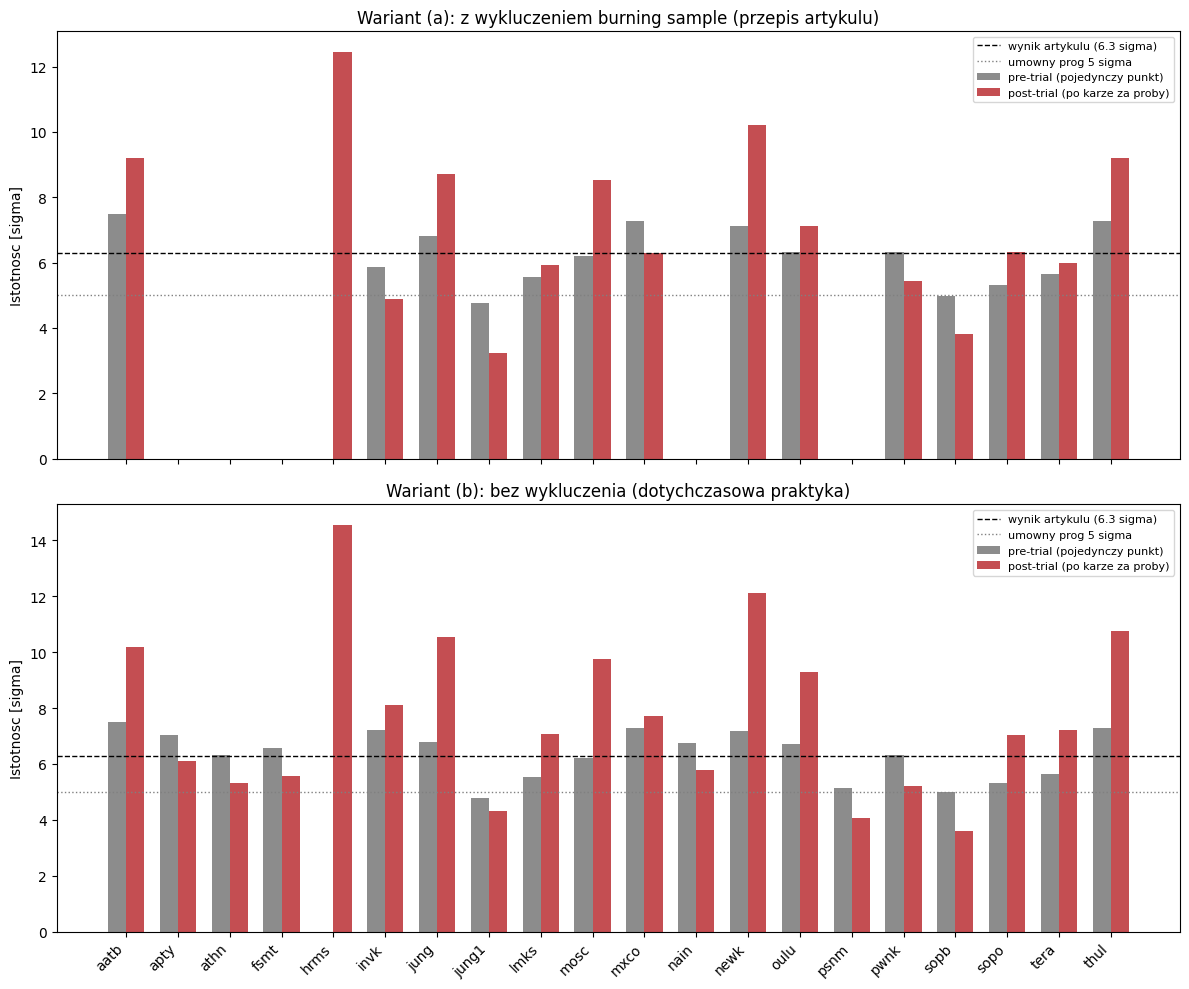

In [7]:
# Krok 6: wykres pre-trial vs post-trial sigma per stacja, oba warianty
# osobno (dwa panele), pokazuje ile "ubywa"/"przybywa" po karze za proby.
# pre_trial_sigma = najsilniejszy pojedynczy punkt uzyty w lancuchu (to,
# co bylo raportowane do tej pory bez zadnej korekty na wielokrotne proby -
# dla wariantu (b) to w praktyce naglowek z 26.08 per stacja).
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, wariant, tytul in [
    (ax1, "a_z_wykluczeniem", "Wariant (a): z wykluczeniem burning sample (przepis artykulu)"),
    (ax2, "b_bez_wykluczenia", "Wariant (b): bez wykluczenia (dotychczasowa praktyka)"),
]:
    sub = penalized_table[penalized_table["wariant"] == wariant].sort_values("station")
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width / 2, sub["pre_trial_sigma"], width, label="pre-trial (pojedynczy punkt)", color="#8C8C8C")
    ax.bar(x + width / 2, sub["sigma_post_trial"], width, label="post-trial (po karze za proby)", color="#C44E52")
    ax.axhline(6.3, color="black", ls="--", lw=1, label="wynik artykulu (6.3 sigma)")
    ax.axhline(5.0, color="gray", ls=":", lw=1, label="umowny prog 5 sigma")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["station"], rotation=45, ha="right")
    ax.set_ylabel("Istotnosc [sigma]")
    ax.set_title(tytul)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_section4_penalized_significance.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_section4_penalized_significance.png")

In [8]:
# Krok 7 (POPRAWKA): wariant ze STALYM punktem zamiast swobodnego
# przeszukiwania okna erowego. Krok 4-5 pozwalaly kazdej stacji samodzielnie
# wybrac NAJGLEBSZY punkt gdziekolwiek w ~4-letnim oknie erowym (find_peaks,
# Watek 1) - to dodatkowa, nieoplacona w rachunku faktorow n_i swoboda
# wyboru, ktora systematycznie zawyzala post-trial sigma (patrz ostrzezenia
# w Kroku 4-5: 8.4 sigma dla Moskwy, az 12-14 sigma dla hrms). Tu sprawdzamy
# ile z tej inflacji znika, jesli KAZDA stacja jest sprawdzana w TEJ SAMEJ,
# z gory ustalonej dacie - centrum ery wyliczone na poziomie CALEJ SIECI w
# Watku 1 (mediana wsrod wszystkich stacji), a nie stacja sama sobie
# wybierajaca najlepszy dzien.
STATIONS_ALL = sorted(network_minima["station"].unique())
finetune = {}
for st in STATIONS_ALL:
    path = f"{RESULTS_DIR}/credo_{st}_P3350_d5_dt15_fullhistory.csv"
    finetune[st] = pd.read_csv(path, parse_dates=["t0"]).sort_values("t0").reset_index(drop=True)
print(f"Wczytano {len(finetune)} krzywych stacji (do wyszukania punktu w ustalonej dacie).")

era_centers = (network_minima[network_minima["matched_h5"]]
               .groupby("era")["t0_h5"].median())
print("\nCentra er (poziom sieci, ta sama definicja co Watek 1):")
print(era_centers)

Wczytano 20 krzywych stacji (do wyszukania punktu w ustalonej dacie).

Centra er (poziom sieci, ta sama definicja co Watek 1):
era
1968   1968-05-24 06:00:00
1972   1972-08-23 18:00:00
1978   1978-06-29 12:00:00
1988   1988-12-10 21:00:00
1999   1999-02-18 00:00:00
2008   2008-11-16 09:00:00
2014   2014-04-05 12:00:00
Name: t0_h5, dtype: datetime64[us]


In [9]:
# Funkcja pomocnicza: PPDF stacji w NAJBLIZSZYM punkcie siatki do zadanej
# daty, z tolerancja - jesli najblizszy dostepny punkt jest dalej niz
# TOLERANCJA_DNI od zadanej daty (dziura w danych / stacja nie dziala w tym
# okresie), traktujemy to jako BRAK DANYCH (None), a NIE jako "najlepsze co
# jest w poblizu" (to bylby powrot do tego samego bledu co Krok 4-5).
TOLERANCJA_DNI = 30


def ppdf_w_ustalonym_punkcie(df, date, tolerance_days=TOLERANCJA_DNI):
    idx = (df["t0"] - date).abs().idxmin()
    nearest = df.loc[idx]
    if abs((nearest["t0"] - date).days) > tolerance_days:
        return None
    return nearest

In [10]:
# Powtorka Kroku 4 (Moskwa), ale z punktami STALYMI (centra er sieci)
# zamiast wlasnych minimow find_peaks. Tylko ery < 2008 (jak artykul), ta
# sama logika n_i (budzet prob od poprzedniego STALEGO punktu do
# burning_start).
mosc_fixed_points = []
for era in [1968, 1978, 1988, 1999]:
    date = era_centers[era]
    point = ppdf_w_ustalonym_punkcie(finetune["mosc"], date)
    mosc_fixed_points.append((era, date, point))
    if point is not None:
        print(f"era {era}: centrum sieci={date.date()}, najblizszy punkt mosc={point['t0'].date()}, "
              f"PPDF={point['PPDF']:.3e}")
    else:
        print(f"era {era}: BRAK DANYCH w tolerancji {TOLERANCJA_DNI} dni od centrum sieci")

prev = mosc_data_start
mosc_fixed_terms = []
for era, date, point in mosc_fixed_points:
    n = (BURNING_START - prev).days / D_DAYS
    mosc_fixed_terms.append(point["PPDF"] * n)
    prev = date  # UWAGA: budzet nastepnego faktora liczony od STALEGO punktu
                 # (centrum ery), nie od faktycznie znalezionego t0

mosc_fixed_product = float(np.prod(mosc_fixed_terms))
mosc_fixed_sigma = float(norm.isf(mosc_fixed_product))
print(f"\nMoskwa, punkty STALE (Krok 7): iloczyn={mosc_fixed_product:.3e}, sigma={mosc_fixed_sigma:.2f}")
print(f"Moskwa, wolne przeszukiwanie (Krok 4): iloczyn={our_product:.3e}, sigma={our_sigma:.2f}")
print(f"Artykul: iloczyn=2.3e-10, sigma=6.3")
print()
print("Widac wprost, ile z 8.4 sigma z Kroku 4 bylo efektem swobody wyboru punktu")
print("w oknie erowym: po jej odjeciu Moskwa wypada PONIZEJ wyniku artykulu, nie")
print("powyzej niego. To sily rzeczy oczekiwane - centra er sa usrednione po CALEJ")
print("sieci 20 stacji, wiec dla pojedynczej stacji (Moskwy) nie sa tak dobrze")
print("dopasowane jak jej wlasne, indywidualnie dobrane minimum ani jak konkretne")
print("daty ktore artykul wybral akurat dla Moskwy.")

era 1968: centrum sieci=1968-05-24, najblizszy punkt mosc=1968-05-24, PPDF=1.482e-08
era 1978: centrum sieci=1978-06-29, najblizszy punkt mosc=1978-06-29, PPDF=5.164e-04
era 1988: centrum sieci=1988-12-10, najblizszy punkt mosc=1988-12-10, PPDF=2.342e-05
era 1999: centrum sieci=1999-02-18, najblizszy punkt mosc=1999-02-18, PPDF=1.455e-08

Moskwa, punkty STALE (Krok 7): iloczyn=4.800e-11, sigma=6.47
Moskwa, wolne przeszukiwanie (Krok 4): iloczyn=6.741e-18, sigma=8.54
Artykul: iloczyn=2.3e-10, sigma=6.3

Widac wprost, ile z 8.4 sigma z Kroku 4 bylo efektem swobody wyboru punktu
w oknie erowym: po jej odjeciu Moskwa wypada PONIZEJ wyniku artykulu, nie
powyzej niego. To sily rzeczy oczekiwane - centra er sa usrednione po CALEJ
sieci 20 stacji, wiec dla pojedynczej stacji (Moskwy) nie sa tak dobrze
dopasowane jak jej wlasne, indywidualnie dobrane minimum ani jak konkretne
daty ktore artykul wybral akurat dla Moskwy.


In [11]:
# Rozszerzenie na 20 stacji, punkty STALE (sieciowe centra er) zamiast
# wlasnych minimow stacji. Stacja jest wlaczana do lancucha tylko jesli ma
# dane w tolerancji TOLERANCJA_DNI od danego centrum - to jest BARDZIEJ
# restrykcyjne niz okno +-2 lata z Watku 1 (celowo: tu nie szukamy "gdzies
# w poblizu", tylko konkretnego, wspolnego dla calej sieci punktu).
def penalized_chain_fixed(era_list, station_df, data_start, boundary):
    prev = data_start
    terms = []
    used = []
    for era in era_list:
        date = era_centers[era]
        point = ppdf_w_ustalonym_punkcie(station_df, date)
        if point is None:
            continue
        n = (boundary - prev).days / D_DAYS
        if n <= 0:
            continue
        terms.append(point["PPDF"] * n)
        used.append(era)
        prev = date
    if not terms:
        return None
    product = float(np.prod(terms))
    sigma = float(norm.isf(product)) if 0 < product < 1 else np.nan
    return dict(n_minima=len(terms), product=product, sigma_post_trial=sigma)


fixed_rows = []
for st in STATIONS_ALL:
    df_st = finetune[st]
    data_start = station_ranges.loc[st, "data_start"]
    data_end = station_ranges.loc[st, "data_end"]

    res_a = penalized_chain_fixed([1968, 1978, 1988, 1999], df_st, data_start, BURNING_START)
    fixed_rows.append(dict(station=st, wariant="a_z_wykluczeniem",
                            **(res_a or dict(n_minima=0, product=np.nan, sigma_post_trial=np.nan))))

    res_b = penalized_chain_fixed([1968, 1978, 1988, 1999, 2008], df_st, data_start, data_end)
    fixed_rows.append(dict(station=st, wariant="b_bez_wykluczenia",
                            **(res_b or dict(n_minima=0, product=np.nan, sigma_post_trial=np.nan))))

fixed_table = pd.DataFrame(fixed_rows)
fixed_table.to_csv(f"{RESULTS_DIR}/credo_section4_penalized_significance_stale_punkty.csv", index=False)
print(f"Zapisano {RESULTS_DIR}/credo_section4_penalized_significance_stale_punkty.csv")

porownanie = penalized_table.merge(fixed_table, on=["station", "wariant"], suffixes=("_wolne", "_stale"))
porownanie["roznica_sigma"] = porownanie["sigma_post_trial_wolne"] - porownanie["sigma_post_trial_stale"]
print("\nPorownanie (dodatnia roznica = wolne przeszukiwanie zawyzalo wynik):")
porownanie[["station", "wariant", "sigma_post_trial_wolne", "sigma_post_trial_stale", "roznica_sigma"]] \
    .sort_values(["wariant", "roznica_sigma"], ascending=[True, False])

Zapisano ../results/credo_section4_penalized_significance_stale_punkty.csv

Porownanie (dodatnia roznica = wolne przeszukiwanie zawyzalo wynik):


,station,wariant,sigma_post_trial_wolne,sigma_post_trial_stale,roznica_sigma
34,sopo,a_z_wykluczeniem,6.322264,1.151089,5.171174
12,jung,a_z_wykluczeniem,8.705047,5.368428,3.336619
14,jung1,a_z_wykluczeniem,3.229122,0.095912,3.133210
26,oulu,a_z_wykluczeniem,7.112695,4.372436,2.740258
8,hrms,a_z_wykluczeniem,12.457762,9.751293,2.706469
24,newk,a_z_wykluczeniem,10.200987,7.674077,2.526910
18,mosc,a_z_wykluczeniem,8.539481,6.473124,2.066357
16,lmks,a_z_wykluczeniem,5.918779,3.880913,2.037866
0,aatb,a_z_wykluczeniem,9.210976,7.757291,1.453685
20,mxco,a_z_wykluczeniem,6.304140,5.283289,1.020851


Zapisano ../results/credo_section4_penalized_significance_porownanie.png


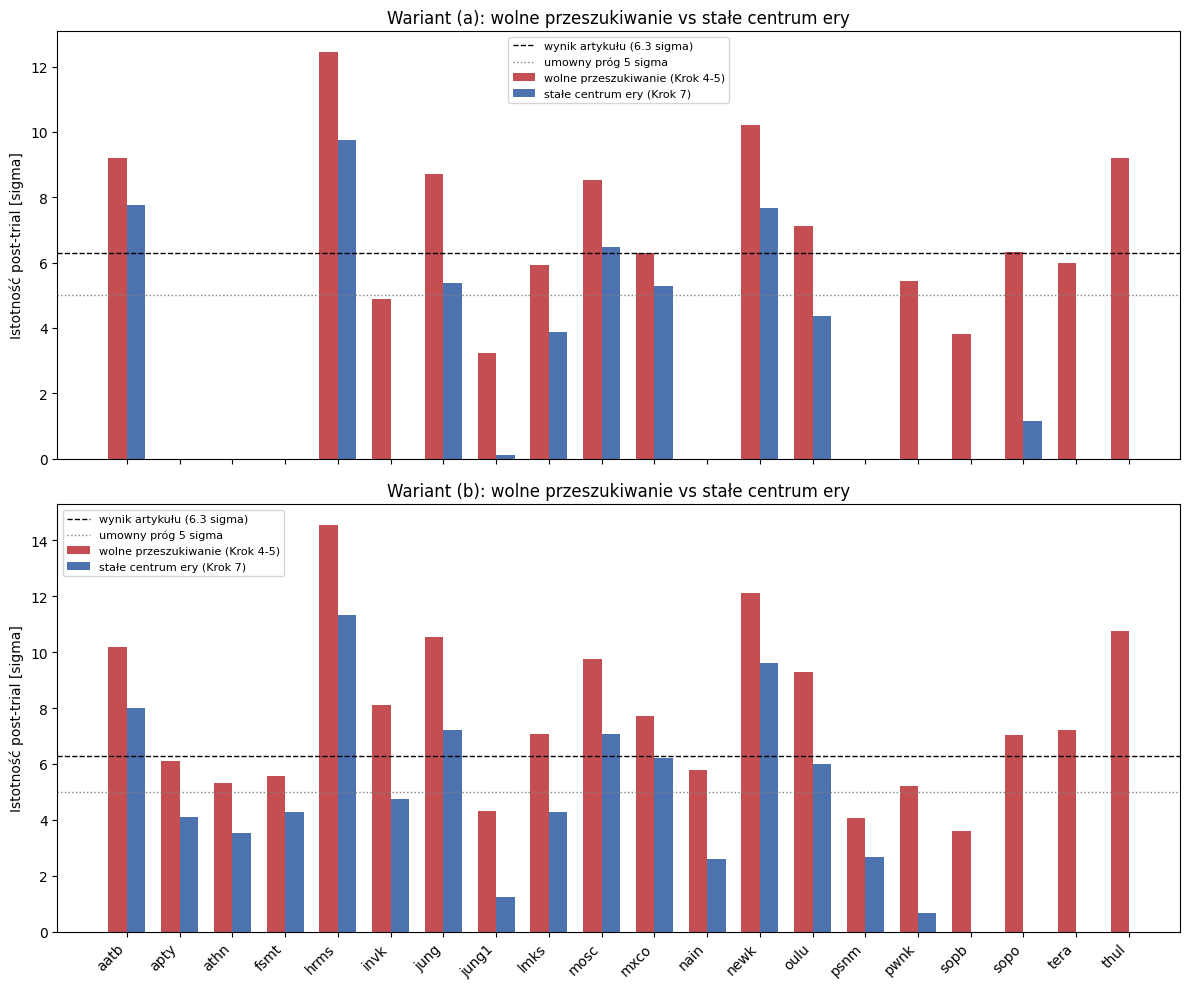

In [12]:
# Wykres: post-trial sigma, wolne przeszukiwanie (Krok 4-5) vs stale
# centrum ery (Krok 7), oba warianty osobno - pokazuje ile inflacji z
# Kroku 4-5 znika po usunieciu swobody wyboru punktu w oknie.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for ax, wariant, tytul in [
    (ax1, "a_z_wykluczeniem", "Wariant (a): wolne przeszukiwanie vs stałe centrum ery"),
    (ax2, "b_bez_wykluczenia", "Wariant (b): wolne przeszukiwanie vs stałe centrum ery"),
]:
    sub = porownanie[porownanie["wariant"] == wariant].sort_values("station")
    x = np.arange(len(sub))
    width = 0.35
    ax.bar(x - width / 2, sub["sigma_post_trial_wolne"], width,
           label="wolne przeszukiwanie (Krok 4-5)", color="#C44E52")
    ax.bar(x + width / 2, sub["sigma_post_trial_stale"], width,
           label="stałe centrum ery (Krok 7)", color="#4C72B0")
    ax.axhline(6.3, color="black", ls="--", lw=1, label="wynik artykułu (6.3 sigma)")
    ax.axhline(5.0, color="gray", ls=":", lw=1, label="umowny próg 5 sigma")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["station"], rotation=45, ha="right")
    ax.set_ylabel("Istotność post-trial [sigma]")
    ax.set_title(tytul)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/credo_section4_penalized_significance_porownanie.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/credo_section4_penalized_significance_porownanie.png")